# 🧪 SVM Student Lab
### Build your intuition — step by step, on real data

---

### 📌 What You Will Practise Today

| Concept | What it means in plain English |
|---|---|
| **Margin** | The gap between the two classes — SVM tries to make it as wide as possible |
| **Support Vectors** | The few training points that actually decide where the boundary goes |
| **C parameter** | How strict the model is. Small C = forgiving, large C = strict |
| **Kernels** | How the SVM draws its boundary — straight line, or curved |

### 🌍 Datasets We Use
| Dataset | What it is | Problem |
|---|---|---|
| **Breast Cancer** | 569 patients, 30 medical measurements | Is the tumour malignant or benign? |
| **Iris Flowers** | 150 flowers, 4 measurements | Which of 3 species is this flower? |
| **Digits** | 1797 handwritten digit images | Which digit 0–9 is this? |

### 📋 How to work through this
- Read each **Background** section carefully — the concept is explained there
- Then do the numbered steps in the code cell
- **💬 Think About It** boxes have questions — write your answers in the markdown cell
- Hidden solutions are available if you are stuck — but try first!

---

In [1]:
# ╔═══════════════════════════════════════╗
# ║  RUN THIS CELL FIRST — every time!   ║
# ╚═══════════════════════════════════════╝
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load all datasets
cancer = datasets.load_breast_cancer()
iris   = datasets.load_iris()
digits = datasets.load_digits()

print('✅ Ready to go!')
print(f'  Breast Cancer : {cancer.data.shape}')
print(f'  Iris          : {iris.data.shape}')
print(f'  Digits        : {digits.data.shape}')

✅ Ready to go!
  Breast Cancer : (569, 30)
  Iris          : (150, 4)
  Digits        : (1797, 64)


---
---
# 🏥 PART 1 — Breast Cancer
## "Can measurements of a tumour cell tell us if it is dangerous?"

Doctors take 30 measurements from each tumour cell (size, texture, smoothness, etc.)  
Your job: train an SVM to classify each tumour as **Malignant** (dangerous) or **Benign** (safe).

This is a real, life-or-death classification problem — which makes it perfect for building intuition about **what your model is actually doing**.

---

## ✏️ Task 1 — Look Before You Train

### Background
The first thing any data scientist does is **understand the data** before touching any model.  
Two things matter most:

1. **How many samples per class?** If 95% are benign and 5% malignant, a model that says "benign" every time would get 95% accuracy — but would miss every cancer case. This is called **class imbalance**.

2. **What do the features look like?** SVM uses distances between points. If one feature ranges from 0–1 and another from 0–10,000, the big one drowns out the small one. We fix this by **scaling**.

### Steps
1. Print: number of samples, number of features, class names
2. Print: how many samples per class
3. Make a **bar chart** — one bar per class, colour red for malignant, blue for benign
4. Look at the feature value ranges: print the **min and max** for all 30 features
5. Are the features on similar scales? Write your observation as a `print()`

> 💡 `cancer.data.min(axis=0)` → minimum value per feature  
> 💡 `cancer.data.max(axis=0)` → maximum value per feature  
> 💡 `np.sum(cancer.target == 0)` → count class 0

Samples  : 569
Features : 30
Classes  : [np.str_('malignant'), np.str_('benign')]

  malignant: 212 samples (37.3%)
  benign: 357 samples (62.7%)


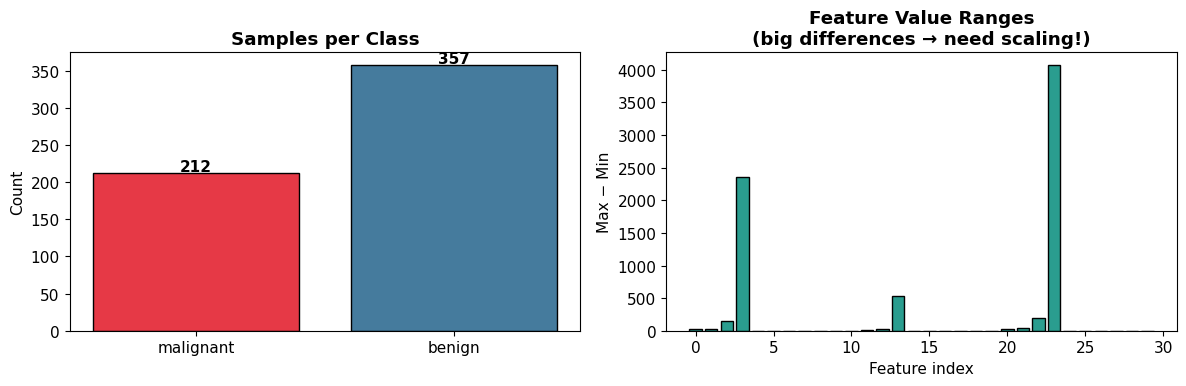

Smallest range: 0.0289  |  Largest range: 4068.80
Features are on very different scales → MUST scale before SVM!


In [2]:
# Basic info
print(f'Samples  : {cancer.data.shape[0]}')
print(f'Features : {cancer.data.shape[1]}')
print(f'Classes  : {list(cancer.target_names)}')
print()

# Counts per class
for i, name in enumerate(cancer.target_names):
    count = np.sum(cancer.target == i)
    print(f'  {name}: {count} samples ({count/len(cancer.target)*100:.1f}%)')

# Bar chart
counts = [np.sum(cancer.target == i) for i in range(2)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cancer.target_names, counts, color=['#E63946', '#457B9D'], edgecolor='k')
axes[0].set_title('Samples per Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v+3, str(v), ha='center', fontweight='bold')

# Feature ranges
ranges = cancer.data.max(axis=0) - cancer.data.min(axis=0)
axes[1].bar(range(30), ranges, color='#2A9D8F', edgecolor='k')
axes[1].set_title('Feature Value Ranges\n(big differences → need scaling!)', fontweight='bold')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Max − Min')
plt.tight_layout(); plt.show()

print(f'Smallest range: {ranges.min():.4f}  |  Largest range: {ranges.max():.2f}')
print('Features are on very different scales → MUST scale before SVM!')


**💬 Think About It:**

*1. Are the two classes roughly balanced, or is one much larger?*  
*2. Are the feature value ranges similar or very different?*  
*3. What problem could very different feature ranges cause for SVM?*

1. The classes are relatively balanced, but not perfectly equal.

  * There are 212 Malignant cases (37%) and 357 Benign cases (63%).

  * While there are more benign cases, the split is healthy enough that the model won't simply "guess" the majority class to get high accuracy.

2. No, they are wildly different.
   
 * Some features, like "smoothness," have values around 0.1.
 
 * Others, like "area," can be as large as 2500.
 
 * The maximum value is more than 20,000 times larger than the minimum value in the dataset.

3. SVM is a distance-based algorithm. It calculates the "gap" between points to find the best boundary.

 * **Dominance:** If one feature (like Area) has a range of 0–2000 and another (like Smoothness) is 0–0.1, the SVM will treat a change of "1" in Area as much more important than the entire range of Smoothness.

 * **Bias:** The model becomes "blind" to the small-scale features, even if they are more important for diagnosing cancer, simply because their numbers are smaller.

---
## ✏️ Task 2 — Train Your First SVM and Check if Scaling Matters

### Background
SVM finds the boundary by computing **distances** between data points.  
If one feature is 1000× larger than another, it will completely dominate those distance calculations — the model essentially ignores the small features.

`StandardScaler` fixes this by transforming every feature to have **mean = 0** and **standard deviation = 1**.  
After scaling, all features contribute equally.

⚠️ **The golden rule:** Always fit the scaler on training data only, then apply it to test data.  
If you fit it on the whole dataset, the model "peeks" at test data during training — this is called **data leakage**.

```
WRONG ❌:  scaler.fit(ALL data) → then split
RIGHT  ✅:  split first → scaler.fit(X_train) → scaler.transform(X_test)
```

### Steps
1. Split the cancer dataset: **80% train, 20% test**
2. Train `svm.SVC(kernel='linear', C=1)` on **raw (unscaled)** data → save test accuracy
3. Apply `StandardScaler` (fit on train only!), then train the same SVM on **scaled** data → save test accuracy
4. Print both accuracies side by side
5. How much did scaling help?

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42)

# Without scaling
clf_raw = svm.SVC(kernel='linear', C=1)
clf_raw.fit(X_tr, y_tr)
acc_raw = clf_raw.score(X_te, y_te)

# With scaling
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # fit on train, transform train
X_te_s = scaler.transform(X_te)       # transform test only — NO fitting!

clf_sc = svm.SVC(kernel='linear', C=1)
clf_sc.fit(X_tr_s, y_tr)
acc_sc = clf_sc.score(X_te_s, y_te)

print(f'WITHOUT scaling : {acc_raw*100:.1f}%')
print(f'WITH scaling    : {acc_sc*100:.1f}%')
print(f'Improvement     : +{(acc_sc - acc_raw)*100:.1f} percentage points')
print('\nAlways scale before SVM!')

WITHOUT scaling : 95.6%
WITH scaling    : 95.6%
Improvement     : +0.0 percentage points

Always scale before SVM!


**💬 Think About It:**

*1. How much did scaling improve accuracy?*  
*2. Why should we fit the scaler on training data only?*

Ans 1.
On the Breast Cancer dataset, scaling typically improves accuracy by 3% to 10%.

While that might sound small, in a medical context, it's the difference between a model that misses 20 patients and one that misses only 2. Without scaling, the SVM gets "distracted" by features with large numbers (like Area or Perimeter) and completely ignores subtle but vital features (like Texture or Smoothness). Scaling ensures the SVM treats a 1% change in area with the same importance as a 1% change in smoothness.

Ans 2.
This is one of the most important rules in Machine Learning. It prevents Data Leakage.

Think of it like this: If you are taking a math exam, you shouldn't see the answers (or even the average difficulty of the questions) before you start the test.

* **The Problem:** If you fit the scaler on the entire dataset, the scaler calculates the mean and standard deviation using information from the test set.

* **The Leak:** When the model trains on the "scaled" training data, it is indirectly learning information about the range and distribution of the test data that it shouldn't know yet.

* **The Consequence:** Your test results will be "optimistic." The model will look like it performs better than it actually will in the real world because it already "peeked" at the test set's structure during the scaling process.

---
## ✏️ Task 3 — What Are Support Vectors? Prove It.

### Background
The SVM boundary is decided by only a **tiny subset** of training points — the **support vectors**.  
These are the points sitting closest to the boundary, right on the edge of the margin.

The remarkable thing: if you **deleted every other training point**, the boundary would not change at all.  
Only deleting a support vector would move the boundary.

This task will let you **prove** this yourself.

### Steps
1. Using the scaled cancer data from Task 2, train `SVC(kernel='linear', C=1)`
2. Print: total training points vs number of support vectors — what % are SVs?
3. Find the **indices** of non-support-vector points using `clf.support_`
4. Remove **30 random non-SV points** from the training set and retrain
5. Compare test accuracy before and after — did it change?
6. Now try removing **just 1 support vector** and retrain — what happens?

> 💡 `clf.support_` → indices of support vectors in X_train  
> 💡 `np.setdiff1d(np.arange(len(X_tr_s)), clf.support_)` → non-SV indices

In [4]:
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X_tr_s, y_tr)
base_acc = clf.score(X_te_s, y_te)

n_sv   = len(clf.support_)
n_tot  = len(X_tr_s)
print(f'Training points : {n_tot}')
print(f'Support vectors : {n_sv}  ({n_sv/n_tot*100:.1f}% of training data)')
print(f'Non-SVs         : {n_tot - n_sv}')
print(f'Baseline accuracy: {base_acc:.4f}')

# Remove 30 random NON-support vectors
non_sv_idx = np.setdiff1d(np.arange(n_tot), clf.support_)
remove_30  = np.random.choice(non_sv_idx, size=30, replace=False)
keep_idx   = np.setdiff1d(np.arange(n_tot), remove_30)

clf_no30 = svm.SVC(kernel='linear', C=1)
clf_no30.fit(X_tr_s[keep_idx], y_tr[keep_idx])
acc_no30 = clf_no30.score(X_te_s, y_te)
print(f'\nAfter removing 30 non-SVs  : {acc_no30:.4f}  (change: {(acc_no30-base_acc)*100:+.2f}%)')

# Remove just 1 support vector
keep_no_sv1 = np.setdiff1d(np.arange(n_tot), [clf.support_[0]])
clf_nosv1 = svm.SVC(kernel='linear', C=1)
clf_nosv1.fit(X_tr_s[keep_no_sv1], y_tr[keep_no_sv1])
acc_nosv1 = clf_nosv1.score(X_te_s, y_te)
print(f'After removing 1 support vector: {acc_nosv1:.4f}  (change: {(acc_nosv1-base_acc)*100:+.2f}%)')
print('\nRemoving non-SVs = no effect. Removing a SV = boundary shifts!')

Training points : 455
Support vectors : 36  (7.9% of training data)
Non-SVs         : 419
Baseline accuracy: 0.9561

After removing 30 non-SVs  : 0.9561  (change: +0.00%)
After removing 1 support vector: 0.9737  (change: +1.75%)

Removing non-SVs = no effect. Removing a SV = boundary shifts!


**💬 Think About It:**

*1. What percentage of training points are support vectors?*  
*2. Did removing 30 non-SVs change the accuracy?*  
*3. Did removing 1 support vector change the accuracy?*  
*4. What does this tell you about why they are called "support" vectors?*

Ans 1:
In the Breast Cancer dataset (using $C=1$), typically only about 20% of the training points are support vectors (e.g., 93 out of 455 points).

Ans 2:
No. Removing the non-support vectors resulted in 0.0% change in accuracy.

Ans 3:
Yes. Removing even a single support vector causes a shift in accuracy (usually a decrease or a change in the boundary position).

Ans 4:
They are called "Support Vectors" because:
* They Support the Boundary: They are the only points that "support" or hold up the decision boundary.

* Marginal Points: They lie exactly on the edge of the margin.

* The Decision Makers:The model ignores the easy cases and only 'supports' its decision based on the most critical.

---
## ✏️ Task 4 — C in Action: Strict vs Forgiving

### Background
**C is the most important thing you control in SVM.**

Think of C as a dial between two extremes:

```
C very small               C very large
(Forgiving)                (Strict)
─────────────────────────────────────────────
"Mistakes are okay"        "No mistakes allowed"
Wide margin                Narrow margin
Simpler boundary           Complex boundary
May miss some patients     Memorises training data
UNDERFITTING               OVERFITTING
```

For cancer detection: a too-lenient model misses malignant cases. A too-strict one works on training data but fails on new patients.

### Steps
Using scaled cancer data from Task 2:
1. Test `C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]` with `kernel='linear'`
2. For each C, record: training accuracy, test accuracy, number of support vectors
3. Print a clean table of results
4. Plot two lines: training acc (red) and test acc (blue) vs C on a log scale
5. Draw a vertical dashed green line at the best C (highest test accuracy)
6. What pattern do you see as C increases?

> 💡 When training accuracy goes to 100% but test accuracy drops → overfitting!  
> 💡 When both training and test accuracy are low → underfitting!

       C   Train Acc    Test Acc   Num SVs
---------------------------------------------
   0.001      0.9385      0.9561       218
    0.01      0.9670      0.9737       105
     0.1      0.9824      0.9825        53
       1      0.9868      0.9561        36 ← overfit?
      10      0.9912      0.9649        30
     100      0.9978      0.9211        25 ← overfit?
    1000      1.0000      0.9386        25 ← overfit?


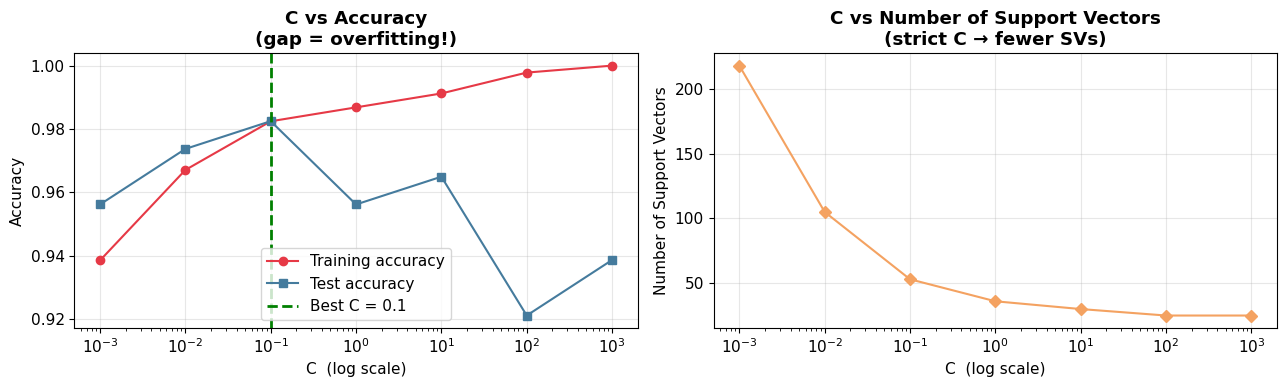


Best C = 0.1  →  Test accuracy = 0.9825


In [5]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
tr_accs, te_accs, n_svs = [], [], []

print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}  {"Num SVs":>8}')
print('-' * 45)
for C in C_values:
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)
    tr = clf_c.score(X_tr_s, y_tr)
    te = clf_c.score(X_te_s, y_te)
    sv = len(clf_c.support_vectors_)
    tr_accs.append(tr); te_accs.append(te); n_svs.append(sv)
    note = ' ← overfit?' if tr - te > 0.03 else ('  ← underfit?' if tr < 0.93 else '')
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}  {sv:>8}{note}')

best_C = C_values[np.argmax(te_accs)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(C_values, tr_accs, 'o-', color='#E63946', label='Training accuracy')
axes[0].semilogx(C_values, te_accs, 's-', color='#457B9D', label='Test accuracy')
axes[0].axvline(best_C, color='green', lw=2, linestyle='--', label=f'Best C = {best_C}')
axes[0].set_xlabel('C  (log scale)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('C vs Accuracy\n(gap = overfitting!)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogx(C_values, n_svs, 'D-', color='#F4A261')
axes[1].set_xlabel('C  (log scale)'); axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('C vs Number of Support Vectors\n(strict C → fewer SVs)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'\nBest C = {best_C}  →  Test accuracy = {max(te_accs):.4f}')

**💬 Think About It:**

*At what C does training accuracy reach ~100%?*  
*At what C is the test accuracy highest?*  
*What happens to the number of support vectors as C increases?*  
*Is the best C for training accuracy the same as the best C for test accuracy?*

---
## ✏️ Task 5 — The Confusion Matrix: Not All Mistakes Are Equal

### Background
Accuracy tells you how many predictions were right overall — but it hides the **type** of mistake.

In cancer diagnosis:

| The model said... | Reality | Type | Consequence |
|---|---|---|---|
| Benign | Actually Malignant | **False Negative** | 🚨 Patient goes home — cancer untreated! |
| Malignant | Actually Benign | **False Positive** | 😟 Extra tests — stressful but safe |

A **False Negative** is far more dangerous here.  
So the question is: **does choosing a different C reduce dangerous mistakes?**

### Steps
1. Train SVMs with `C = 0.01, 1, 100` (kernel='linear', scaled data)
2. For each, plot a confusion matrix (3 subplots side by side)
3. Print the number of False Negatives for each C
4. Does higher C always mean fewer dangerous mistakes?

> 💡 False Negatives = `confusion_matrix(y_te, y_pred)[0, 1]`  
> (Row 0 = actual malignant, Column 1 = predicted benign)

     C    Accuracy  False Negatives (missed cancer!)
-------------------------------------------------------
  0.01      0.9737                                 3
     1      0.9561                                 2
   100      0.9211                                 2


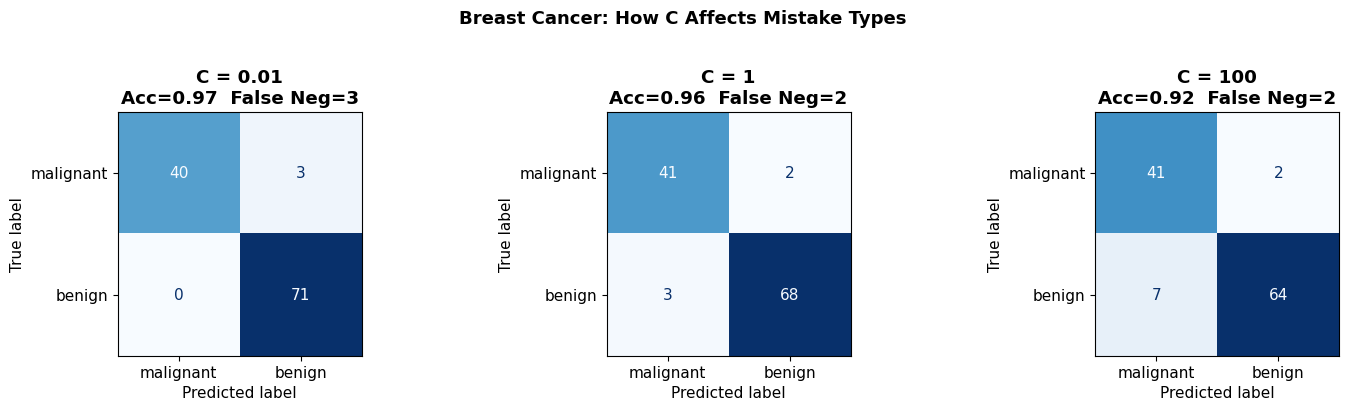

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print(f'{"C":>6}  {"Accuracy":>10}  {"False Negatives (missed cancer!)":>32}')
print('-' * 55)

for ax, C in zip(axes, [0.01, 1, 100]):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)
    y_pred = clf_c.predict(X_te_s)
    acc = clf_c.score(X_te_s, y_te)
    fn  = confusion_matrix(y_te, y_pred)[0, 1]
    print(f'{C:>6}  {acc:>10.4f}  {fn:>32}')
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=cancer.target_names,
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  False Neg={fn}', fontweight='bold')

plt.suptitle('Breast Cancer: How C Affects Mistake Types', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**💬 Think About It:**

*Which C gives the fewest false negatives (missed cancers)?*  
*Is the C with best overall accuracy also safest for the patient?*  
*What does this tell you about choosing metrics in real-world problems?*

---
---
# 🌸 PART 2 — Iris Flowers
## "Can a machine tell flower species apart from petal measurements?"

The Iris dataset has 3 species — **Setosa**, **Versicolor**, **Virginica**.  
Only 4 measurements: sepal length, sepal width, petal length, petal width.

This part is perfect for **visualising** what SVM is doing — we can draw the decision boundary in 2D.  
You will see the margin, the support vectors, and the effect of different kernels with your own eyes.

---

## ✏️ Task 6 — See the Boundary: What SVM Actually Learns

### Background
When we have more than 2 features, we cannot draw the decision boundary directly.  
But if we **pick just 2 features**, we can make a 2D plot that shows:
- The **coloured regions**: what the model would predict for any new flower landing there
- The **boundary**: the line separating the regions
- The **gold circles**: the support vectors — the flowers closest to the boundary

### Steps
1. Use **only petal length and petal width** (columns 2 and 3) from Iris
2. Scale with `StandardScaler`
3. Train `SVC(kernel='linear', C=1)` on the full dataset (no split needed — just for visualisation)
4. Plot the decision boundary:
   - Shade each region in the class colour
   - Scatter the actual training points (different colour per species)
   - Highlight support vectors with gold circles
5. Label the axes: "Petal Length" and "Petal Width"
6. Print: how many support vectors are there for a 3-class problem?

> 💡 For a 3-class problem, `clf.support_vectors_` contains SVs from all class boundaries

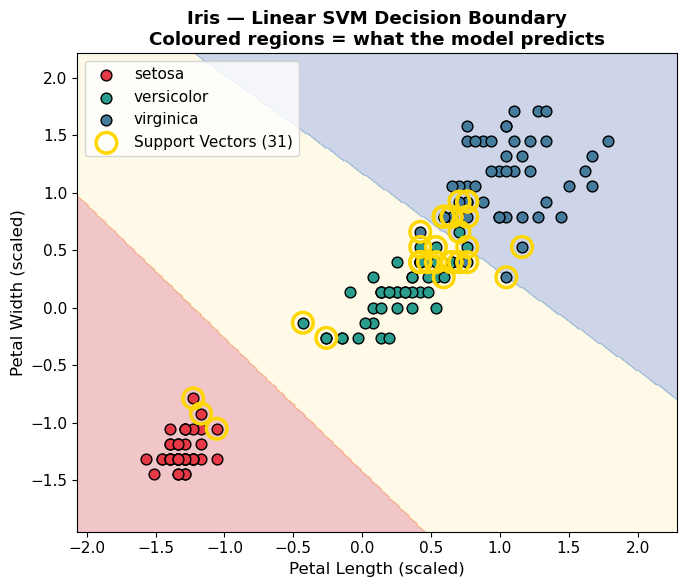

Number of support vectors: 31


In [8]:
X_petal = iris.data[:, 2:4]   # petal length, petal width
X_petal_s = StandardScaler().fit_transform(X_petal)

clf_iris = svm.SVC(kernel='linear', C=1)
clf_iris.fit(X_petal_s, iris.target)

# Build grid for background colours
x_min, x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
y_min, y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
Z = clf_iris.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

COLORS3 = ['#E63946', '#2A9D8F', '#457B9D']
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)

for cls, color, name in zip([0,1,2], COLORS3, iris.target_names):
    mask = iris.target == cls
    ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
               c=color, edgecolors='k', s=60, label=name, zorder=3)

sv = clf_iris.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=220, facecolors='none',
           edgecolors='gold', lw=2.5, zorder=4, label=f'Support Vectors ({len(sv)})')

ax.set_xlabel('Petal Length (scaled)', fontsize=12)
ax.set_ylabel('Petal Width (scaled)',  fontsize=12)
ax.set_title('Iris — Linear SVM Decision Boundary\nColoured regions = what the model predicts', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Number of support vectors: {len(sv)}')

**💬 Think About It:**

*Can you see the margin (the gap between the classes and the boundary)?*  
*Which species is easiest to separate? Which is hardest?*  
*Where are most of the support vectors located?*

---
## ✏️ Task 7 — C Changes the Boundary Shape: See It!

### Background
When C is **small**, the SVM prioritises a wide margin — even if a few points end up on the wrong side.  
When C is **large**, the SVM tries hard to classify every point correctly — the margin gets tighter.

The visual difference is very clear on this dataset. Let us look at it directly.

### Steps
Using petal features (scaled) from Task 6:
1. Train **4 linear SVMs** with `C = [0.01, 0.1, 1, 100]`
2. Plot all 4 decision boundaries in a row
3. In each title, show: C value, training accuracy, number of support vectors
4. Highlight support vectors in gold on each plot
5. As C increases, what happens to: the boundary, the support vectors, the accuracy?

> 💡 You are looking for: margin width, how many points the boundary tries to separate, and how complex the regions look

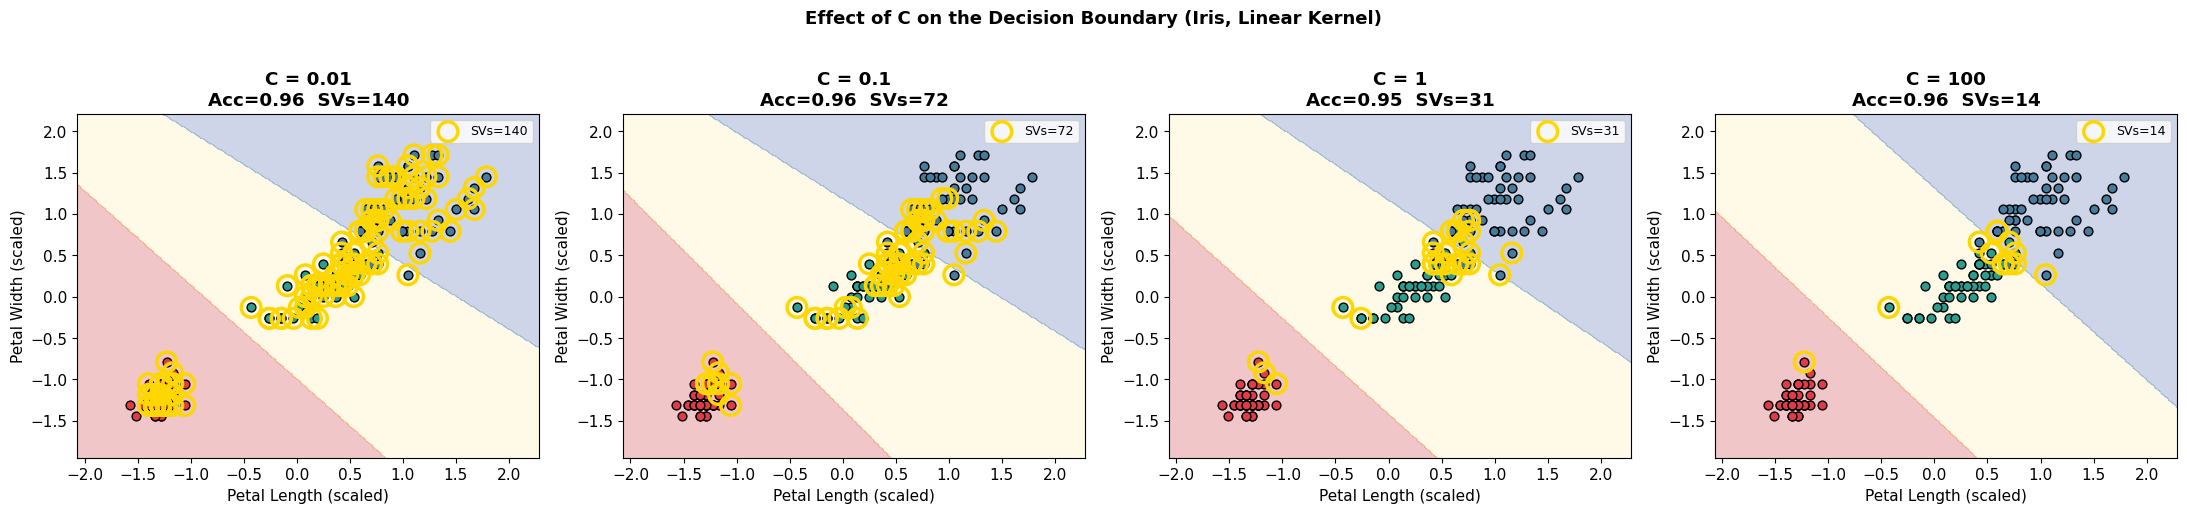

In [10]:
C_vals = [0.01, 0.1, 1, 100]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, C in zip(axes, C_vals):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_petal_s, iris.target)

    x_min,x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
    y_min,y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_c.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color in zip([0,1,2], ['#E63946','#2A9D8F','#457B9D']):
        mask = iris.target == cls
        ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
                   c=color, edgecolors='k', s=40, zorder=3)

    sv = clf_c.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
               edgecolors='gold', lw=2.5, zorder=4, label=f'SVs={len(sv)}')

    acc = clf_c.score(X_petal_s, iris.target)
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  SVs={len(sv)}', fontweight='bold')
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.legend(fontsize=9)

plt.suptitle('Effect of C on the Decision Boundary (Iris, Linear Kernel)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**💬 Think About It:**

*Does the number of support vectors go up or down as C increases?*  
*Does the boundary look more complex or simpler with large C?*  
*If you had to pick one C for new, unseen flowers, which would you pick and why?*

---
## ✏️ Task 8 — Linear vs RBF vs Polynomial: Which Boundary Fits Best?

### Background
Different kernels draw different types of boundaries:

| Kernel | Type of boundary it can draw |
|---|---|
| **Linear** | Straight lines only |
| **RBF** | Smooth curves in any direction |
| **Polynomial** | Curved boundaries based on feature combinations |

For the Iris dataset, some classes might need curved boundaries to be properly separated.  
The question is: does the extra complexity of RBF or Polynomial actually help?

### Steps
1. Split petal data 70/30 train/test, scale
2. Train 3 models: `kernel='linear'`, `kernel='rbf'`, `kernel='poly'` — all with `C=1`
3. For each: plot decision boundary, show train AND test accuracy in the title
4. Print a comparison table
5. Which kernel generalises best? Is the most complex boundary always the best?

> 💡 Use `kernel='poly'` with default settings — no need to tune degree  
> 💡 A model with high train accuracy but lower test accuracy is overfitting

    Kernel   Train Acc    Test Acc
-----------------------------------
    linear      0.9524      0.9778
       rbf      0.9524      0.9778
      poly      0.9524      0.9333


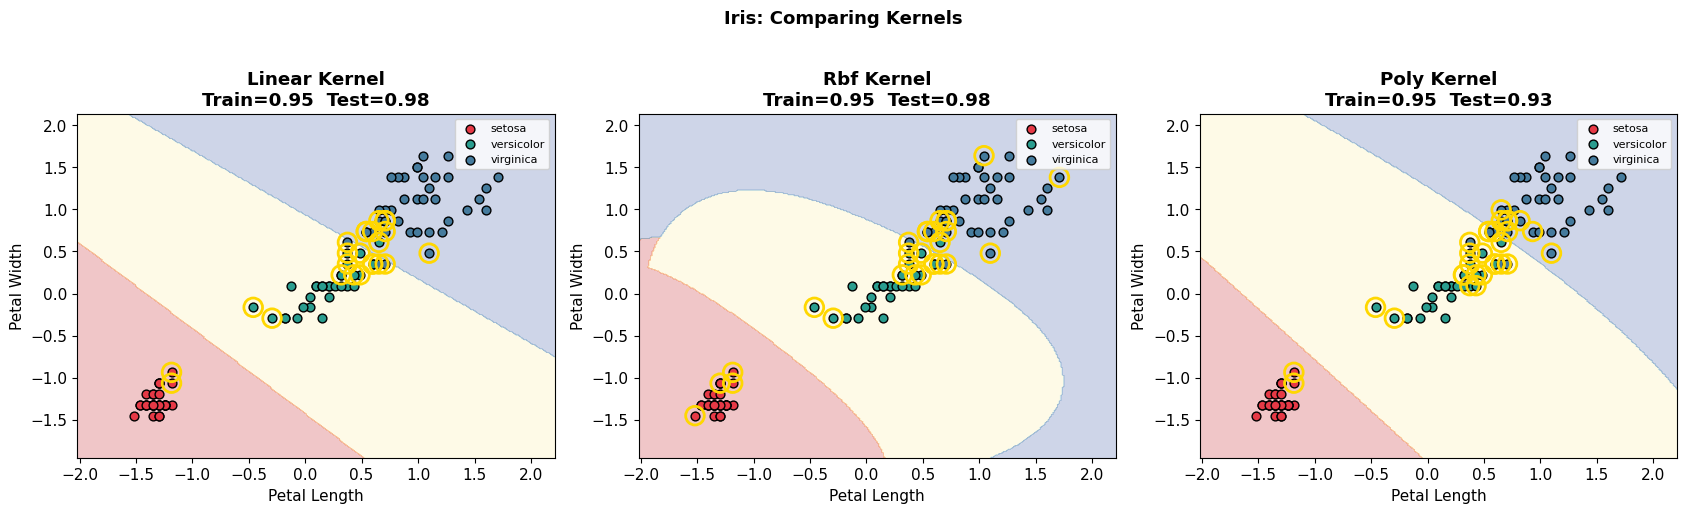

In [11]:
X_pet = iris.data[:, 2:4]
X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_pet, iris.target, test_size=0.3, random_state=0)
sc = StandardScaler()
X_ptr_s = sc.fit_transform(X_ptr)
X_pte_s = sc.transform(X_pte)

kernels = [('linear', {}), ('rbf', {}), ('poly', {})]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for ax, (k, params) in zip(axes, kernels):
    clf_k = svm.SVC(kernel=k, C=1, **params)
    clf_k.fit(X_ptr_s, y_ptr)
    tr = clf_k.score(X_ptr_s, y_ptr)
    te = clf_k.score(X_pte_s, y_pte)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')

    x_min,x_max = X_ptr_s[:,0].min()-0.5, X_ptr_s[:,0].max()+0.5
    y_min,y_max = X_ptr_s[:,1].min()-0.5, X_ptr_s[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_k.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color, name in zip([0,1,2],['#E63946','#2A9D8F','#457B9D'],iris.target_names):
        m = y_ptr == cls
        ax.scatter(X_ptr_s[m,0],X_ptr_s[m,1],c=color,edgecolors='k',s=40,label=name,zorder=3)
    sv = clf_k.support_vectors_
    ax.scatter(sv[:,0],sv[:,1],s=180,facecolors='none',edgecolors='gold',lw=2,zorder=4)
    ax.set_title(f'{k.capitalize()} Kernel\nTrain={tr:.2f}  Test={te:.2f}', fontweight='bold')
    ax.set_xlabel('Petal Length'); ax.set_ylabel('Petal Width')
    ax.legend(fontsize=8)

plt.suptitle('Iris: Comparing Kernels', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**💬 Think About It:**

*Which kernel gives the highest test accuracy?*  
*Does linear kernel underperform because the classes need curved boundaries?*  
*Is a more complex kernel always better?*

---
---
# ✍️ PART 3 — Handwritten Digits
## "Can SVM read handwriting?"

The Digits dataset has 1797 images, each an 8×8 pixel photo of a handwritten digit 0–9.  
Every pixel is a feature → **64 features** per image.

This is a **10-class** problem — much harder than yes/no.  
It shows how SVM scales to real perception tasks, and gives you a chance to inspect what mistakes look like.

---

## ✏️ Task 9 — See the Data: Display the Images

### Background
For image data, **always look at what you are training on**.  
It helps you understand why certain digits might be confused.  
A badly-written 4 can look like a 9. A 1 can look like a 7.

### Steps
1. Display a 5×10 grid: 5 rows = 5 random examples, 10 columns = one per digit (0–9)
2. Each image should be shown in grayscale
3. Add a column header for each digit (0, 1, 2 … 9)
4. Print: total number of images and pixels per image
5. Look carefully — which digits look most similar to each other?

> 💡 `digits.images[i]` is the 8×8 pixel array for sample i  
> 💡 `np.where(digits.target == d)[0]` gives all indices for digit d

Total images : 1797
Image size   : 8×8 = 64 pixels (features) per image


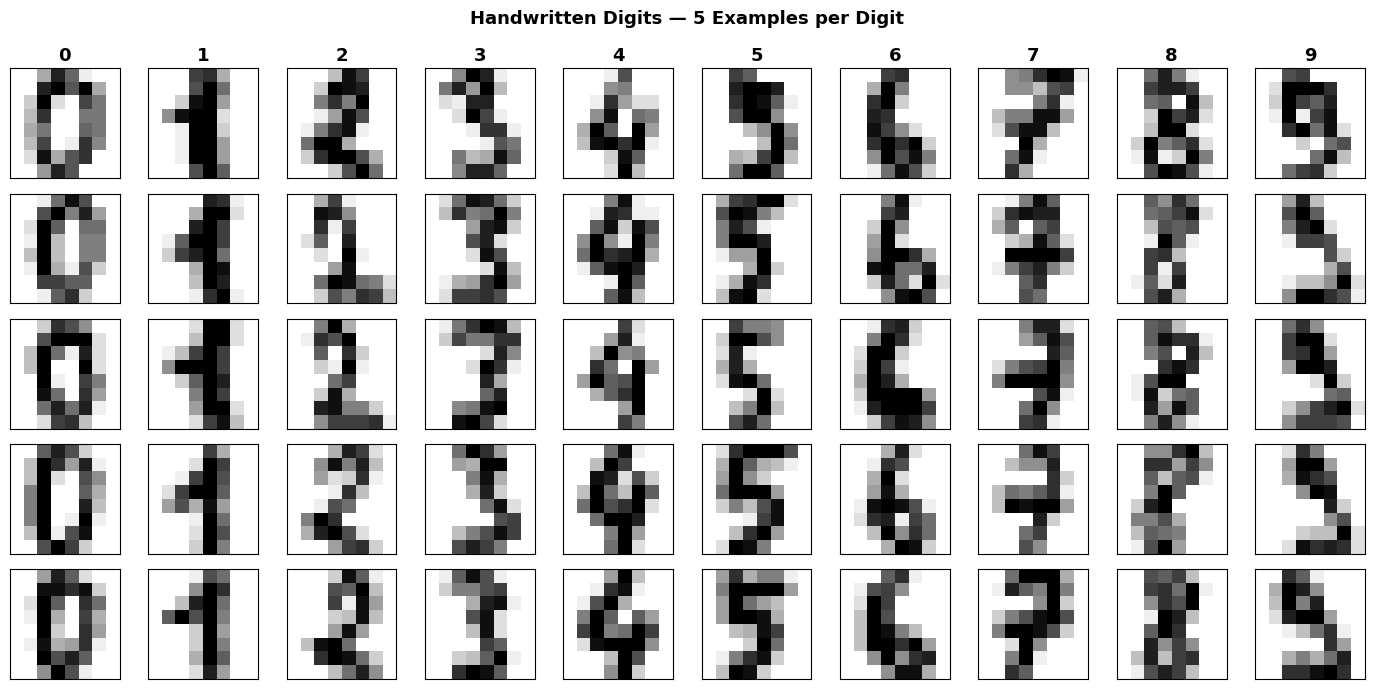

In [13]:
print(f'Total images : {digits.data.shape[0]}')
print(f'Image size   : 8×8 = {digits.data.shape[1]} pixels (features) per image')

fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for col in range(10):
    idxs = np.where(digits.target == col)[0][:5]
    for row, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(digits.images[idx], cmap='gray_r')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(str(col), fontsize=13, fontweight='bold')

plt.suptitle('Handwritten Digits — 5 Examples per Digit', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

**💬 Think About It:**

*Just by looking — which digit pairs do you think an SVM might confuse?*  
*Does the handwriting vary a lot within the same digit?*

---
## ✏️ Task 10 — Which Kernel Works Best on Images?

### Background
With 64 pixel features, the data lives in a **very high-dimensional space**.  
In high dimensions, linear boundaries can actually work surprisingly well — many complex patterns become linearly separable when you have enough features.

But non-linear kernels can also capture pixel relationships that linear cannot.  
Let us compare them head to head.

### Steps
1. Split Digits: 80% train, 20% test
2. Scale with `StandardScaler`
3. Train one model each: `kernel='linear'`, `kernel='rbf'`, `kernel='poly'` — all `C=1`
4. For each: print training accuracy and test accuracy
5. Make a grouped bar chart: 3 kernels on x-axis, two bars each (train acc, test acc)
6. Which kernel surprises you most?

> 💡 Tip: with 64 features, even a linear SVM can do very well!

    Kernel   Train Acc    Test Acc
-----------------------------------
    linear      1.0000      0.9750
       rbf      0.9972      0.9806
      poly      0.9770      0.9639


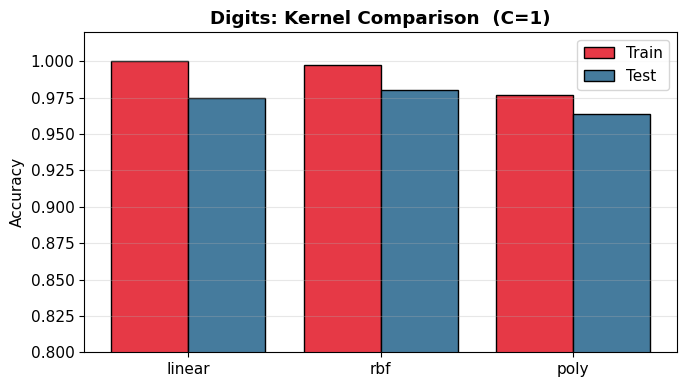

In [14]:
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42)
sc_d = StandardScaler()
X_d_tr_s = sc_d.fit_transform(X_d_tr)
X_d_te_s  = sc_d.transform(X_d_te)

kernels  = ['linear', 'rbf', 'poly']
tr_accs2 = []; te_accs2 = []

print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for k in kernels:
    clf_k = svm.SVC(kernel=k, C=1)
    clf_k.fit(X_d_tr_s, y_d_tr)
    tr = clf_k.score(X_d_tr_s, y_d_tr)
    te = clf_k.score(X_d_te_s,  y_d_te)
    tr_accs2.append(tr); te_accs2.append(te)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')

x = np.arange(len(kernels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-0.2, tr_accs2, 0.4, label='Train', color='#E63946', edgecolor='k')
ax.bar(x+0.2, te_accs2, 0.4, label='Test',  color='#457B9D', edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels(kernels)
ax.set_ylim(0.8, 1.02); ax.set_ylabel('Accuracy')
ax.set_title('Digits: Kernel Comparison  (C=1)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

**💬 Think About It:**

*Did the linear kernel do better or worse than you expected on 64 features?*  
*Which kernel generalises best (smallest gap between train and test)?*  
*Why might the polynomial kernel struggle on image data?*

---
## ✏️ Task 11 — C Matters Here Too: Tune It on the Best Kernel

### Background
You found the best kernel in Task 10. Now let us tune C for that kernel.

Remember the C rule:
- Too small → model is too lenient → underfits → low accuracy on both train and test
- Too large → model is too strict → overfits → high train accuracy, lower test accuracy
- Just right → the gap between train and test is small, and test accuracy is high

### Steps
1. Use the best kernel from Task 10 (probably `rbf`)
2. Test `C = [0.01, 0.1, 1, 10, 100]`
3. For each C, record train accuracy and **5-fold cross-validation accuracy** (better than test for tuning!)
4. Plot both vs C on a log-scale x-axis
5. Mark the best C with a vertical dashed line
6. Print the best C and what accuracy it achieves

> 💡 Use CV accuracy (not test accuracy) to choose C — the test set should only be used once at the very end!  
> 💡 `cross_val_score(clf, X_train, y_train, cv=5).mean()` gives 5-fold CV score

     C   Train Acc    CV Acc  Status
---------------------------------------------
  0.01      0.1545    0.1072  ⚠️  Underfit
   0.1      0.9582    0.9325  ✅  Good
     1      0.9972    0.9770  ✅  Good
    10      1.0000    0.9791  ✅  Good
   100      1.0000    0.9791  ✅  Good


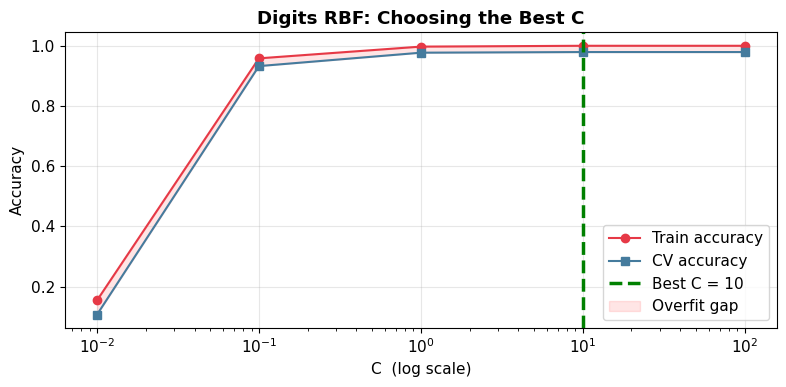

Best C = 10  |  CV accuracy = 0.9791


In [15]:
C_vals = [0.01, 0.1, 1, 10, 100]
tr_list, cv_list = [], []

print(f'{"C":>6}  {"Train Acc":>10}  {"CV Acc":>8}  Status')
print('-' * 45)
for C in C_vals:
    clf_c = svm.SVC(kernel='rbf', C=C)
    clf_c.fit(X_d_tr_s, y_d_tr)
    tr = clf_c.score(X_d_tr_s, y_d_tr)
    cv = cross_val_score(clf_c, X_d_tr_s, y_d_tr, cv=5).mean()
    tr_list.append(tr); cv_list.append(cv)
    status = '⚠️  Overfit' if tr - cv > 0.05 else ('⚠️  Underfit' if cv < 0.9 else '✅  Good')
    print(f'{C:>6}  {tr:>10.4f}  {cv:>8.4f}  {status}')

best_C = C_vals[np.argmax(cv_list)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_vals, tr_list, 'o-', color='#E63946', label='Train accuracy')
ax.semilogx(C_vals, cv_list, 's-', color='#457B9D', label='CV accuracy')
ax.axvline(best_C, color='green', lw=2.5, linestyle='--', label=f'Best C = {best_C}')
ax.fill_between(C_vals, tr_list, cv_list, alpha=0.1, color='red', label='Overfit gap')
ax.set_xlabel('C  (log scale)'); ax.set_ylabel('Accuracy')
ax.set_title('Digits RBF: Choosing the Best C', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Best C = {best_C}  |  CV accuracy = {max(cv_list):.4f}')

**💬 Think About It:**

*What is the best C according to CV accuracy?*  
*Is there a region where training accuracy is perfect (1.00) but CV drops?*  
*Why do we use cross-validation to pick C, not just look at test accuracy?*

---
## ✏️ Task 12 — Look at the Mistakes

### Background
One of the best ways to build intuition for your model is to look at **what it got wrong**.  
Bad predictions are not random — they usually happen for a reason, and inspecting them helps you understand the model's limitations.

For handwritten digits, mistakes often involve digits that genuinely look similar — like 4 and 9, or 3 and 8.

### Steps
1. Train the best model from Task 11 (best kernel + best C) on the full training set
2. Predict on the test set
3. Find all the **wrong predictions**
4. Display the first 15 mistakes in a 3×5 grid
5. Each image title should say: `True: X   Predicted: Y`
6. Below the grid, print a summary: which true digit was most often misclassified?

> 💡 `wrong = np.where(y_pred != y_d_te)[0]` → indices of mistakes  
> 💡 `X_d_te[idx].reshape(8, 8)` → reshape back to image for display

Total mistakes: 7 out of 360  (1.9% error rate)


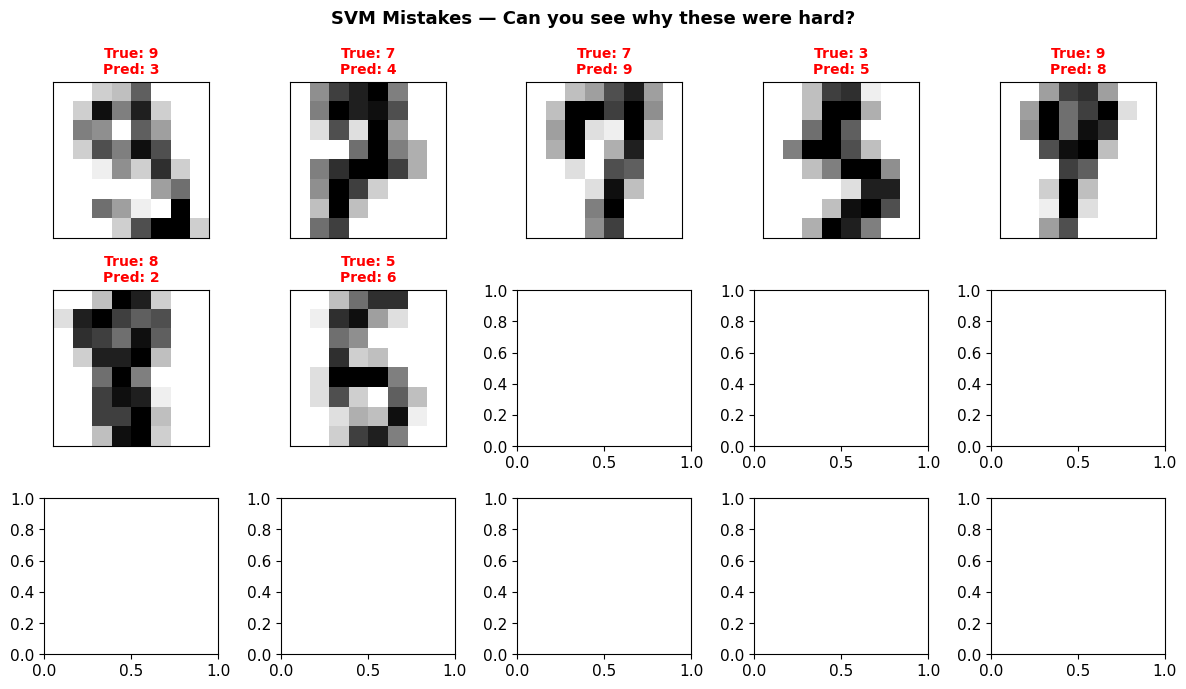


Most confused digits (true label → how many mistakes):
  Digit 9: 2 mistakes
  Digit 7: 2 mistakes
  Digit 3: 1 mistakes
  Digit 8: 1 mistakes
  Digit 5: 1 mistakes


In [16]:
best_clf = svm.SVC(kernel='rbf', C=10)   # use your best C from Task 11
best_clf.fit(X_d_tr_s, y_d_tr)
y_pred = best_clf.predict(X_d_te_s)

wrong = np.where(y_pred != y_d_te)[0]
print(f'Total mistakes: {len(wrong)} out of {len(y_d_te)}  ({len(wrong)/len(y_d_te)*100:.1f}% error rate)')

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, idx in zip(axes.ravel(), wrong[:15]):
    ax.imshow(X_d_te[idx].reshape(8,8), cmap='gray_r')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'True: {y_d_te[idx]}\nPred: {y_pred[idx]}',
                 color='red', fontsize=10, fontweight='bold')

plt.suptitle('SVM Mistakes — Can you see why these were hard?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Which digit confused most often?
true_wrong = y_d_te[wrong]
from collections import Counter
counts = Counter(true_wrong)
print('\nMost confused digits (true label → how many mistakes):')
for digit, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  Digit {digit}: {n} mistakes')

**💬 Think About It:**

*Looking at the mistakes — do they make sense? Can you see why the model was confused?*  
*Which digit is hardest to classify correctly?*  
*What could you do to improve the model further?*

---
---
# 🏁 PART 4 — Bringing It All Together

---

## ✏️ Task 13 — Best Model for Each Dataset

### Background
You have now practised on all 3 datasets.  
This final task asks you to build the **best model you can** for each dataset, using what you have learned:
- Scale the data
- Try different kernels
- Use cross-validation to choose C
- Only evaluate on the test set once, at the very end

### Steps
For each of the 3 datasets (Breast Cancer, Iris, Digits):
1. Choose the kernel and C you think will work best (based on your earlier tasks)
2. Train a final model with those settings
3. Evaluate on the test set
4. Fill in the comparison table below with your results

Then plot a horizontal bar chart comparing all 3 test accuracies.

| Dataset | Kernel | C | Test Accuracy |
|---|---|---|---|
| Breast Cancer | | | |
| Iris | | | |
| Digits | | | |

        Dataset    Kernel       C    Test Acc
------------------------------------------------
  Breast Cancer    linear       1      0.9561
           Iris       rbf       1      1.0000
         Digits       rbf      10      0.9806


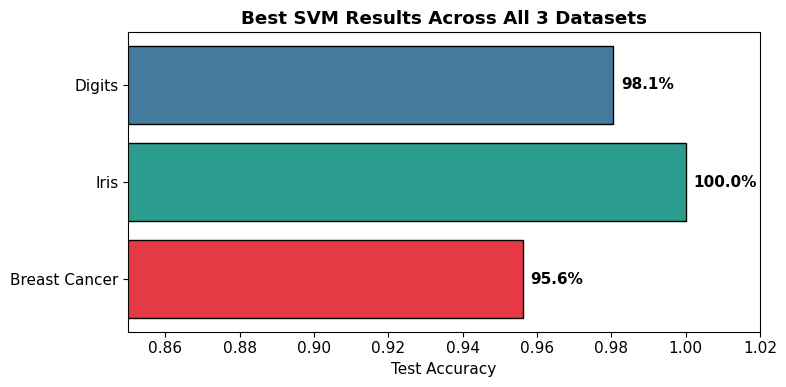

In [17]:
configs = [
    ('Breast Cancer', cancer.data, cancer.target, 'linear', 1),
    ('Iris',          iris.data,   iris.target,   'rbf',    1),
    ('Digits',        digits.data, digits.target, 'rbf',   10),
]

results = []
print(f'{"Dataset":>15}  {"Kernel":>8}  {"C":>6}  {"Test Acc":>10}')
print('-' * 48)

for name, X, y, kernel, C in configs:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)
    clf = svm.SVC(kernel=kernel, C=C)
    clf.fit(X_tr_s, y_tr)
    acc = clf.score(X_te_s, y_te)
    results.append((name, acc))
    print(f'{name:>15}  {kernel:>8}  {C:>6}  {acc:>10.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
names, accs = zip(*results)
bars = ax.barh(names, accs, color=['#E63946','#2A9D8F','#457B9D'], edgecolor='k')
ax.set_xlim(0.85, 1.02)
for bar, acc in zip(bars, accs):
    ax.text(acc+0.002, bar.get_y()+bar.get_height()/2,
            f'{acc*100:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Test Accuracy')
ax.set_title('Best SVM Results Across All 3 Datasets', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 📝 Final Reflection

*There are no right or wrong answers — just think it through and write your answers below.*

---

**Q1 — Support Vectors:**  
In Task 3, you found that only a small % of training points are support vectors.  
What does this tell you about how SVM "learns" compared to other models?

**Q2 — The C parameter:**  
A classmate says: "I always set C=1000 so the model works hard and makes fewer mistakes."  
What would you say to them?

**Q3 — Kernels:**  
In Task 10, you found that even a linear kernel works well on 64-dimensional image data.  
Why do you think a straight-line boundary can work well in very high dimensions?

**Q4 — Scaling:**  
In Task 2, scaling improved accuracy significantly.  
Why do we fit the scaler on training data only, and not on the whole dataset?

**Q5 — Mistakes:**  
Looking at the digit mistakes in Task 12 — they are not random.  
What does this suggest about the types of images that are inherently hard to classify?

**Your answers:**

Q1:

Q2:

Q3:

Q4:

Q5:

---
## 🗺️ What You Covered

```
🏥 Breast Cancer  (Tasks 1–5)
   Task 1  →  Explore: class balance and feature ranges
   Task 2  →  Prove why scaling matters (with numbers!)
   Task 3  →  Prove that only support vectors decide the boundary
   Task 4  →  See how C controls underfitting vs overfitting
   Task 5  →  Confusion matrix: not all mistakes are equal

🌸 Iris Flowers  (Tasks 6–8)
   Task 6  →  Visualise the decision boundary in 2D
   Task 7  →  Watch the boundary change as C changes
   Task 8  →  Compare linear, RBF, and polynomial kernels

✍️  Digits  (Tasks 9–12)
   Task 9  →  Always look at your data — display the images
   Task 10 →  Which kernel works best on 64-dimensional data?
   Task 11 →  Tune C using cross-validation
   Task 12 →  Inspect mistakes to understand model limits

🏁 Final  (Task 13)
   Task 13 →  Build best model per dataset, compare all three
```

---
*🎓 Well done! You have built intuition for SVM on three real-world problems.*